# Imports

In [70]:
"""
RNN Character-Level Text Generator (Edgar Allan Poe Corpus)
===========================================================

This notebook demonstrates a full character-level RNN text generation workflow using a cleaned subset of Edgar Allan Poe's writings.
It includes data preprocessing, batching, model definition, training, loss tracking, ONNX export, and basic sampling. The goal is to show end-to-end control over a deep learning pipeline, with a focus on transparency rather than final generation quality.

Highlights:
-----------
- Dataset: Cleaned text from selected Poe works (Project Gutenberg)
- Tokenization: Character-level with full vocab index
- Model: GRU-based RNN with embedding and dense output layers
- Training: Custom early stopping callback with loss threshold
- Logging: Loguru + MLflow + matplotlib + seaborn
- Export: ONNX conversion and sample output generation

Status:
-------
This is a **learning-stage notebook**. Output is garbled, as expected from character-level modeling on a short, poetic corpus.
The purpose is to demonstrate:
- TensorFlow RNN mechanics
- Loss behavior over time
- Dataset generation
- ONNX export for embedded/portable inference

Next Steps (Optional):
----------------------
- Switch to word-level tokenization for more semantic output
- Explore LSTM or multi-layer RNNs
- Train on a much larger and more diverse corpus (e.g., Shakespeare, Wikipedia)
- Replace text generation sampling with temperature annealing

"""

# === Core Utilities ===
import os
import sys
import re
import requests
import math
import time
import json
import uuid
import logging
import warnings
import datetime as dt
import functools
from pathlib import Path

# === Console Formatting & Logging ===
from colorama import Fore, Style
from loguru import logger

# === Data Handling ===
import numpy as np
import pandas as pd

# === Validation ===
from pydantic import BaseModel, Field, ValidationError

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Latex, Math

# === MLflow for Experiment Tracking ===
import mlflow
import mlflow.pytorch
import mlflow.sklearn
from mlflow.data import from_pandas
from mlflow.models.signature import infer_signature

# === ONNX Runtime (optional) ===
import tf2onnx
import onnx
import onnxruntime as ort

# === Scikit-Learn ===
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    OneHotEncoder, OrdinalEncoder
)
from sklearn.linear_model import (
    LogisticRegression, ElasticNet, Ridge, Lasso
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, accuracy_score,
    mean_squared_error, mean_absolute_error, r2_score
)

# === TensorFlow & Keras ===
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Conv2D, MaxPool2D, Flatten, Input,
    Dropout, BatchNormalization
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow import TensorSpec
from tensorflow.keras.datasets import mnist

# === TensorFlow GPU Settings ===
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU memory growth enabled")
    except RuntimeError as e:
        print(e)

tf.config.threading.set_intra_op_parallelism_threads(32)
tf.config.threading.set_inter_op_parallelism_threads(32)

# === Global Warnings Control ===
warnings.filterwarnings('ignore')


✅ GPU memory growth enabled


In [2]:
# --- MLflow Experiment Setup ---
experiment_name = "tf_nlp_with_rnn_raven"
mlflow.set_experiment(experiment_name)

# --- Init MLflow Run ---

# kill unclosed run if exists
if mlflow.active_run():
    mlflow.end_run()

run = mlflow.start_run()

# --- Logging Initialization ---

# Create log directory for the experiment
log_dir = Path("/mnt/mls/logs") / experiment_name
log_dir.mkdir(parents=True, exist_ok=True)

# Define log file path
log_file = log_dir / f"train_{experiment_name}.log"
timestamp = str(dt.datetime.now(dt.timezone.utc).strftime("%Y_%m_%d_%H%M%S"))
run_id = run.info.run_id

logger.remove()

logger = logger.bind(run_id=run_id)
logger = logger.bind(run_id=run_id, timestamp=timestamp)

# File logging with daily rotation and compression
logger.add(
    str(log_file),  # Path to the log file (must be a string, not a Path object)

    format="{extra[timestamp]} | {level} | {extra[run_id]} | {name}:{function}:{line} | {message}",
    # Format of each log line:
    # {time}     - Timestamp (YYYY-MM-DD HH:MM:SS.mmm)
    # {level}    - Log level (INFO, DEBUG, etc.)
    # {name}     - Module name (e.g., 'helper' from 'helper.py')
    # {function} - Name of the function that emitted the log
    # {line}     - Line number where logger was called
    # {message}  - The actual message logged

    level="DEBUG",  # Minimum log level for this handler (includes INFO, WARNING, ERROR, etc.)
    rotation="00:00",  # Automatically rotate log file when "00:00" for daily rotation
    retention="14 days",  # Keep rotated log files for 14 days, then delete them automatically
    compression="zip",  # Compress rotated log files using ZIP format to save space
    enqueue=True,  # Use multiprocessing-safe queue to log from multiple threads/processes safely
    backtrace=True,  # Show full stack trace (even outside of the except block) if an error occurs
    diagnose=False,  # Disable automatic introspection of variables in the traceback (safer for production)
    mode="a",  # Open the log file in append mode (ensures logs aren’t overwritten on script restart)
    filter=lambda record: record["extra"].get("run_id") == run_id  # Optional, if multiple run_ids used
)


def log_time(func):
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        start_time = time.time()
        result = func(*args, **kwargs)
        end_time = time.time()
        logger.info(f"{func.__name__} took {end_time - start_time:.4f} seconds")
        return result

    return wrapper


logger.info("Logger initialized (mlflow.start_run()).")

# Phase 1: Data Preparation

## Load and Clean Text

In [3]:
# # Download The Raven
# raven_url = "https://www.gutenberg.org/cache/epub/1065/pg1065.txt"
# response = requests.get(raven_url, verify=False)
# raven_text = response.text
#
# # Preview first 500 characters
# print(raven_text)

In [4]:
string = '*** START OF THE PROJECT GUTENBERG EBOOK THE RAVEN ***'

print()
print(re.search(r'\*\*\* START .*', string).end())


54


In [5]:
def clean_text(text: str) -> str:
    try:
        header = (re.search(r'\*\*\* START .*', text))
        footer = (re.search(r'\*\*\* END .*', text))
        print(f'Start of text after line: {header.group(0)}')
        print(f'End of text before line: {footer.group(0)}')

        text = text[header.end():footer.start()]

    except AttributeError:
        print(f'could not extract start and end')
        return str()

    text = text.lower()
    text = re.sub(r"[^A-Za-z0-9,;!:.\-\s]+", " ", text)  # remove all but punctuation and text and style chars
    text = re.sub(r'\s+', ' ', text)  # collapse white space

    return text.strip()

In [6]:
# books_list

In [7]:
# cleaned_text = clean_text(raven_text)

In [8]:
# cleaned_text

In [9]:
selected_files = [
    "the_works_of_edgar_allan_poe_volume_1",
    "the_works_of_edgar_allan_poe_volume_2",
    "the_raven",
    "the_fall_of_the_house_of_usher",
    "the_masque_of_the_red_death"
]

In [10]:
cleaned_books = []

for book_path in Path('/mnt/mls/data/books/edgar_allan_poe').glob("*.txt"):
    if any(key in book_path.stem for key in selected_files):
        with open(book_path, 'r', encoding='utf-8') as f:
            raw = f.read()
            cleaned = clean_text(raw)
            cleaned_books.append(cleaned)

full_cleaned_text = "\n".join(cleaned_books)


Start of text after line: *** START OF THE PROJECT GUTENBERG EBOOK THE RAVEN, AND THE PHILOSOPHY OF COMPOSITION ***
End of text before line: *** END OF THE PROJECT GUTENBERG EBOOK THE RAVEN, AND THE PHILOSOPHY OF COMPOSITION ***
Start of text after line: *** START OF THE PROJECT GUTENBERG EBOOK THE FALL OF THE HOUSE OF USHER ***
End of text before line: *** END OF THE PROJECT GUTENBERG EBOOK THE FALL OF THE HOUSE OF USHER ***
Start of text after line: *** START OF THE PROJECT GUTENBERG EBOOK THE WORKS OF EDGAR ALLAN POE, THE RAVEN EDITION ***
End of text before line: *** END OF THE PROJECT GUTENBERG EBOOK THE WORKS OF EDGAR ALLAN POE, THE RAVEN EDITION ***
Start of text after line: *** START OF THE PROJECT GUTENBERG EBOOK THE RAVEN ***
End of text before line: *** END OF THE PROJECT GUTENBERG EBOOK THE RAVEN ***
Start of text after line: *** START OF THE PROJECT GUTENBERG EBOOK LE CORBEAU = THE RAVEN ***
End of text before line: *** END OF THE PROJECT GUTENBERG EBOOK LE CORBEAU = THE R

In [11]:
print(f'Length of cleaned text: {len(full_cleaned_text)}')

Length of cleaned text: 3701235


## Tokenize Text

In [12]:
vocab = sorted(set(full_cleaned_text))

In [13]:
len(vocab)

44

In [14]:
char_to_ind = {char: ind for ind, char in enumerate(vocab)}

In [15]:
char_to_ind

{'\n': 0,
 ' ': 1,
 '!': 2,
 ',': 3,
 '-': 4,
 '.': 5,
 '0': 6,
 '1': 7,
 '2': 8,
 '3': 9,
 '4': 10,
 '5': 11,
 '6': 12,
 '7': 13,
 '8': 14,
 '9': 15,
 ':': 16,
 ';': 17,
 'a': 18,
 'b': 19,
 'c': 20,
 'd': 21,
 'e': 22,
 'f': 23,
 'g': 24,
 'h': 25,
 'i': 26,
 'j': 27,
 'k': 28,
 'l': 29,
 'm': 30,
 'n': 31,
 'o': 32,
 'p': 33,
 'q': 34,
 'r': 35,
 's': 36,
 't': 37,
 'u': 38,
 'v': 39,
 'w': 40,
 'x': 41,
 'y': 42,
 'z': 43}

In [16]:
char_to_ind['h']

25

In [17]:
ind_to_char = np.array(vocab)

In [18]:
ind_to_char[14]

'8'

# Phase 2: Dataset Creation

In [19]:
line = '''seraphim whose foot-falls tinkled on the tufted floor. wretch, i cried, thy god hath lent thee by these angels he hath sent thee respite respite and nepenthe from thy memories of lenore!'''

In [20]:
len(line)

186

In [21]:
seq_len = math.ceil(len(line) * 5)  # create seq len rounding up from example text seq

In [22]:
seq_len

930

In [23]:
# assign total sequences
total_num_seq = len(full_cleaned_text) // (seq_len + 1)

In [24]:
total_num_seq

3975

## Build input/target sequence pairs

In [25]:
encoded_text = np.array([char_to_ind[c] for c in full_cleaned_text])
len(encoded_text)

3701235

In [26]:
print(encoded_text[4500:8000])

[32 31 22 ... 33 32 35]


In [27]:
print(full_cleaned_text[4500:8000])

one of his compositions attained its ultimate point of completion. why such a paper has never been given to the world, i am much at a loss to say but, perhaps, the autorial vanity has had more to do with the omission than any one other cause. most writers poets in especial prefer having it understood that they compose by a species of fine phrenzy an ecstatic intuition and would positively shudder at letting the public take a peep behind the scenes, at the elaborate and vacillating crudities of thought at the true purposes seized only at the last moment at the innumerable glimpses of idea that arrived not at the maturity of full view at the fully matured fancies discarded in despair as unmanageable at the cautious selections and rejections at the painful erasures and interpolations in a word, at the wheels and pinions the tackle for scene-shifting the stepladders and demon-traps the cock s feathers, the red paint and the black patches, which, in ninety-nine cases out of the hundred, con

In [28]:
# Create dataset from encoded characters
char_dataset = tf.data.Dataset.from_tensor_slices(encoded_text)

I0000 00:00:1746242020.889869  831364 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 19022 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:01:00.0, compute capability: 8.6


In [29]:
type(char_dataset)

tensorflow.python.data.ops.from_tensor_slices_op._TensorSliceDataset

In [30]:
sequences = char_dataset.batch(seq_len + 1, drop_remainder=True)

In [31]:
sequences

<_BatchDataset element_spec=TensorSpec(shape=(931,), dtype=tf.int64, name=None)>

In [32]:
def create_seq_targets(seq):
    input_txt = seq[:-1]
    target_txt = seq[1:]
    return input_txt, target_txt

In [33]:
char_dataset = tf.data.Dataset.from_tensor_slices(encoded_text)

In [34]:
dataset = sequences.map(create_seq_targets)
preview_dataset = sequences.map(create_seq_targets).take(1)

In [35]:
for input_txt, target_txt in preview_dataset:
    print(input_txt.numpy())
    print(''.join(ind_to_char[input_txt.numpy()]))
    print('\n')
    print(target_txt.numpy())
    print(''.join(ind_to_char[target_txt.numpy()]))

[37 25 22  1 35 18 39 22 31  1 18 31 21  1 37 25 22  1 33 25 26 29 32 36
 32 33 25 42  1 32 23  1 20 32 30 33 32 36 26 37 26 32 31  1 26 29 29 38
 36 37 35 18 37 26 32 31  1 26 29 29 38 36 37 35 18 37 26 32 31 16  1 20
 32 33 42 35 26 24 25 37  1  7 15  6 12  1 19 42  1 37 25 22  1 25 18 35
 40 22 29 29  4 22 39 18 31 36  1 20 32  5  1 29 22 31 32 35 22  1 26 29
 29 38 36 37 35 18 37 26 32 31  1 37 25 22  1 35 18 39 22 31  1 18 31 21
  1 37 25 22  1 33 25 26 29 32 36 32 33 25 42  1 32 23  1 20 32 30 33 32
 36 26 37 26 32 31  1 19 42  1 22 21 24 18 35  1 18 29 29 18 31  1 33 32
 22  1 34 38 18 35 37 32  1 33 25 32 37 32 24 35 18 39 38 35 22  1 22 21
 26 37 26 32 31  1 26 29 29 38 36 37 35 18 37 22 21  1 23 35 32 30  1 33
 18 26 31 37 26 31 24 36  1 19 42  1 24 18 29 22 31  1 27  5  1 33 22 35
 35 22 37 37  1 37 25 22  1 21 22 20 32 35 18 37 26 32 31 36  1 19 42  1
 40 26 29 29  1 27 22 31 28 26 31 36  1 26 29 29 38 36 37 35 18 37 26 32
 31  1 33 18 38 29  1 22 29 21 22 35  1 18 31 21  1

2025-05-02 20:13:41.301748: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [36]:
batch_size = 4
buffer_size = 1000000

In [37]:
dataset = dataset.shuffle(buffer_size=buffer_size).batch(batch_size, drop_remainder=True)

In [38]:
dataset

<_BatchDataset element_spec=(TensorSpec(shape=(4, 930), dtype=tf.int64, name=None), TensorSpec(shape=(4, 930), dtype=tf.int64, name=None))>

# Phase 3: Define Model

In [39]:
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout, GRU
from tensorflow.keras.losses import sparse_categorical_crossentropy

In [40]:
vocab_size = len(vocab)
vocab_size

44

In [41]:
embed_dim = 64

In [42]:
rnn_neurons = 1026

In [43]:
steps_per_epoch = len(encoded_text) // ((seq_len + 1) * batch_size)

In [44]:
def sparse_cat_loss(y_true, y_pred):
    return sparse_categorical_crossentropy(y_true, y_pred, from_logits=True)

In [45]:
def create_model(vocab_size, embed_dim, rnn_neurons):
    model = Sequential()

    model.add(
        Embedding(
            vocab_size,
            embed_dim,
            input_shape=(None,)
        )
    )

    model.add(
        GRU(
            rnn_neurons,
            return_sequences=True,
            stateful=False,
            recurrent_initializer='glorot_uniform'
        )
    )

    # Final Dense Layer to Predict
    model.add(Dense(vocab_size))

    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0003)
    model.compile(optimizer=optimizer, loss=sparse_cat_loss)

    return model

In [46]:
model = create_model(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    rnn_neurons=rnn_neurons)

model.output_names = ['output']

In [47]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 64)       │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, None, 1026)     │     3,361,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 44)       │        45,188 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,409,180 (13.00 MB)

 Trainable params: 3,409,180 (13.00 MB)

 Non-trainable params: 0 (0.00 B)

# Phase 4: Train

In [48]:
preview_dataset = sequences.map(create_seq_targets).take(1)

for input_example_batch, target_example_batch in preview_dataset:
    # Predict off some random batch
    example_batch_predictions = \
        model(
            tf.expand_dims(input_example_batch, axis=0)
        )

    # Display the dimensions of the predictions
    print(example_batch_predictions.shape, " <- (batch_size, sequence_length, vocab_size)")

(1, 930, 44)  <- (batch_size, sequence_length, vocab_size)


I0000 00:00:1746242022.581236  831559 cuda_dnn.cc:529] Loaded cuDNN version 90800
2025-05-02 20:13:42.659131: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [49]:
sampled_indices = tf.random.categorical(example_batch_predictions[0], num_samples=1)

In [50]:
sampled_indices

<tf.Tensor: shape=(930, 1), dtype=int64, numpy=
array([[ 2],
       [25],
       [30],
       [ 7],
       [19],
       [35],
       [ 1],
       [25],
       [23],
       [ 9],
       [30],
       [34],
       [ 5],
       [20],
       [30],
       [29],
       [33],
       [43],
       [22],
       [36],
       [16],
       [13],
       [29],
       [32],
       [35],
       [11],
       [13],
       [ 0],
       [ 9],
       [ 9],
       [19],
       [38],
       [ 6],
       [28],
       [19],
       [ 2],
       [14],
       [37],
       [33],
       [ 9],
       [24],
       [38],
       [31],
       [17],
       [ 8],
       [28],
       [27],
       [34],
       [ 7],
       [12],
       [16],
       [38],
       [ 1],
       [26],
       [17],
       [20],
       [28],
       [23],
       [23],
       [17],
       [39],
       [ 7],
       [ 0],
       [41],
       [19],
       [12],
       [ 0],
       [37],
       [13],
       [ 6],
       [23],
       [ 5],
       [14],
   

In [51]:
# Reformat to not be a lists of lists
sampled_indices = tf.reshape(sampled_indices, [-1]).numpy()

In [52]:
sampled_indices

array([ 2, 25, 30,  7, 19, 35,  1, 25, 23,  9, 30, 34,  5, 20, 30, 29, 33,
       43, 22, 36, 16, 13, 29, 32, 35, 11, 13,  0,  9,  9, 19, 38,  6, 28,
       19,  2, 14, 37, 33,  9, 24, 38, 31, 17,  8, 28, 27, 34,  7, 12, 16,
       38,  1, 26, 17, 20, 28, 23, 23, 17, 39,  7,  0, 41, 19, 12,  0, 37,
       13,  6, 23,  5, 14, 28, 34, 24, 28,  3, 29, 43, 20, 41, 14,  7, 13,
       32, 39, 11, 29,  5, 36, 25, 41, 14, 15, 10, 34,  8, 43, 12, 23, 27,
       32, 26, 25, 26, 36, 38, 39,  0, 20,  5, 11, 34,  4, 30, 37,  1,  2,
        6, 20, 16, 41, 43, 17, 34, 12, 18, 16,  2, 20, 10, 27, 15, 10, 31,
       10, 12, 16, 19, 27, 35,  9, 11,  0, 41, 32, 16, 32,  4,  3, 21,  7,
       19,  3,  9, 28, 14, 32,  0,  9, 24, 20,  9,  2,  2, 23, 12, 33, 36,
       28,  6, 36, 15, 15, 13, 14, 15, 37, 29, 12, 24, 40,  2,  7, 28,  4,
       31,  1, 24, 41, 26, 34,  4, 21, 21, 37,  7, 27, 29, 30, 38,  1, 36,
        7, 31, 33, 10, 22, 33,  4, 25, 11,  8, 12, 24, 42, 20, 10, 25, 30,
       11, 12,  2, 25, 28

In [53]:
print("Given the input seq: \n")
print("".join(ind_to_char[input_example_batch]))  # no [0]

print("\nNext Char Predictions: \n")
print("".join(ind_to_char[sampled_indices]))


Given the input seq: 

the raven and the philosophy of composition illustration illustration: copyright 1906 by the harwell-evans co. lenore illustration the raven and the philosophy of composition by edgar allan poe quarto photogravure edition illustrated from paintings by galen j. perrett the decorations by will jenkins illustration paul elder and company san francisco and new york contents foreword the philosophy of composition the raven ------------------------------------------------------------------------ foreword the initial intention of the publishers to present the raven without preface, notes, or other extraneous matter that might detract from an undivided appreciation of the poem, has been somewhat modified by the introduction of poe s prose essay, the philosophy of composition. if any justification were necessary, it is to be found both in the unique literary interest of the essay, and in the fact that it is or purports to be 

Next Char Predictions: 

!hm1br hf3mq.cmlpzes

In [54]:
# Check shape of input_example_batch first
print("input_example_batch shape:", input_example_batch.shape)

# If batched input: shape is (batch_size, sequence_length)
if len(input_example_batch.shape) == 2:
    input_seq = input_example_batch[:, :-1]  # x
    target_seq = input_example_batch[:, 1:]  # y

# If single unbatched sequence: shape is (sequence_length,)
elif len(input_example_batch.shape) == 1:
    input_seq = input_example_batch[:-1]  # x
    target_seq = input_example_batch[1:]  # y

else:
    raise ValueError("Unexpected input shape: must be 1D or 2D")

# Show resulting shapes
print("input_seq shape:", input_seq.shape)
print("target_seq shape:", target_seq.shape)


input_example_batch shape: (930,)
input_seq shape: (929,)
target_seq shape: (929,)


In [55]:
print(f'Sequence length: {len(input_seq)}')
print(f'Batch size: {batch_size}')

Sequence length: 929
Batch size: 4


In [56]:
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Total examples: {len(encoded_text)}")
print(f"Batch size: {batch_size}")
print(f"Sequence length: {seq_len}")

Steps per epoch: 993
Total examples: 3701235
Batch size: 4
Sequence length: 930


## Early Stopping

In [57]:
from tensorflow.keras.callbacks import Callback


class StopAtLossValue(Callback):
    def __init__(self, target=0.5):
        super().__init__()
        self.target = target

    def on_epoch_end(self, epoch, logs=None):
        current_loss = logs.get("loss")
        if current_loss is not None and current_loss < self.target:
            print(f"\nStopping training: loss has reached {current_loss:.4f}, below target {self.target:.4f}")
            self.model.stop_training = True


In [58]:
early_stopping = \
    EarlyStopping(
        monitor='loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )

In [59]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_cb = ModelCheckpoint(
    "/mnt/mls/models/tf/moby_rnn_best.keras",
    monitor="loss",
    save_best_only=True,
    mode="min",
    verbose=1,
)

In [60]:
callbacks = [StopAtLossValue(target=0.6), checkpoint_cb]

In [62]:
# dataset = dataset.repeat().prefetch(tf.data.AUTOTUNE)
dataset = dataset.prefetch(tf.data.AUTOTUNE)

# Let's say your original dataset is already batched, shuffled, etc.
dataset_size = len(encoded_text) // ((seq_len + 1) * batch_size)
val_size = int(dataset_size * 0.1)

train_ds = dataset.take(dataset_size - val_size)
val_ds = dataset.skip(dataset_size - val_size)

# steps_per_epoch = len(encoded_text) // ((seq_len + 1) * batch_size)
steps_per_epoch = 2000

epochs = 300000

# Print the loss after each epoch (basic feedback)
history = \
    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        steps_per_epoch=dataset_size - val_size,
        validation_steps=val_size,
        callbacks=callbacks
    )

print(history.history['loss'])


894/894 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.8315
Epoch 16: loss improved from 0.87413 to 0.84108, saving model to /mnt/mls/models/tf/moby_rnn_best.keras
894/894 ━━━━━━━━━━━━━━━━━━━━ 81s 89ms/step - loss: 0.8315 - val_loss: 0.7959
Epoch 17/300000
894/894 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.8017
Epoch 17: loss improved from 0.84108 to 0.81042, saving model to /mnt/mls/models/tf/moby_rnn_best.keras
894/894 ━━━━━━━━━━━━━━━━━━━━ 81s 89ms/step - loss: 0.8017 - val_loss: 0.7551
Epoch 18/300000
894/894 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.7675
Epoch 18: loss improved from 0.81042 to 0.77740, saving model to /mnt/mls/models/tf/moby_rnn_best.keras
894/894 ━━━━━━━━━━━━━━━━━━━━ 81s 89ms/step - loss: 0.7675 - val_loss: 0.7194
Epoch 19/300000
894/894 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.7374
Epoch 19: loss improved from 0.77740 to 0.74587, saving model to /mnt/mls/models/tf/moby_rnn_best.keras
894/894 ━━━━━━━━━━━━━━━━━━━━ 81s 89ms/step - loss: 0.7374 - val_loss: 0.7011


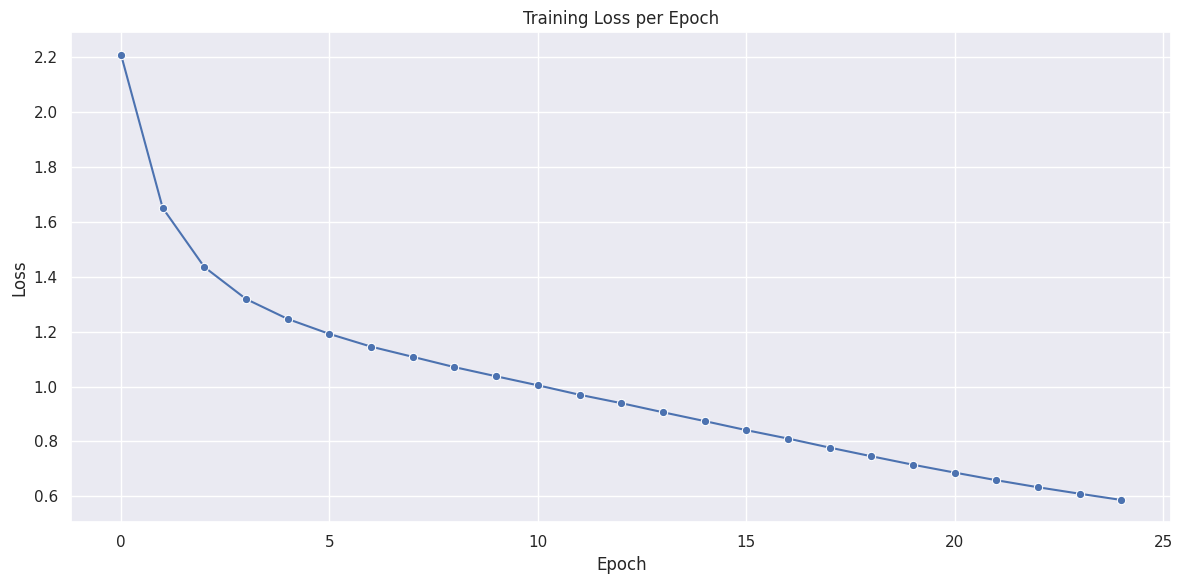

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert loss history to DataFrame for easier plotting
loss_df = pd.DataFrame(history.history)

# Plot using seaborn
plt.figure(figsize=(12, 6))
sns.lineplot(data=loss_df, x=loss_df.index, y='loss', marker='o')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.show()


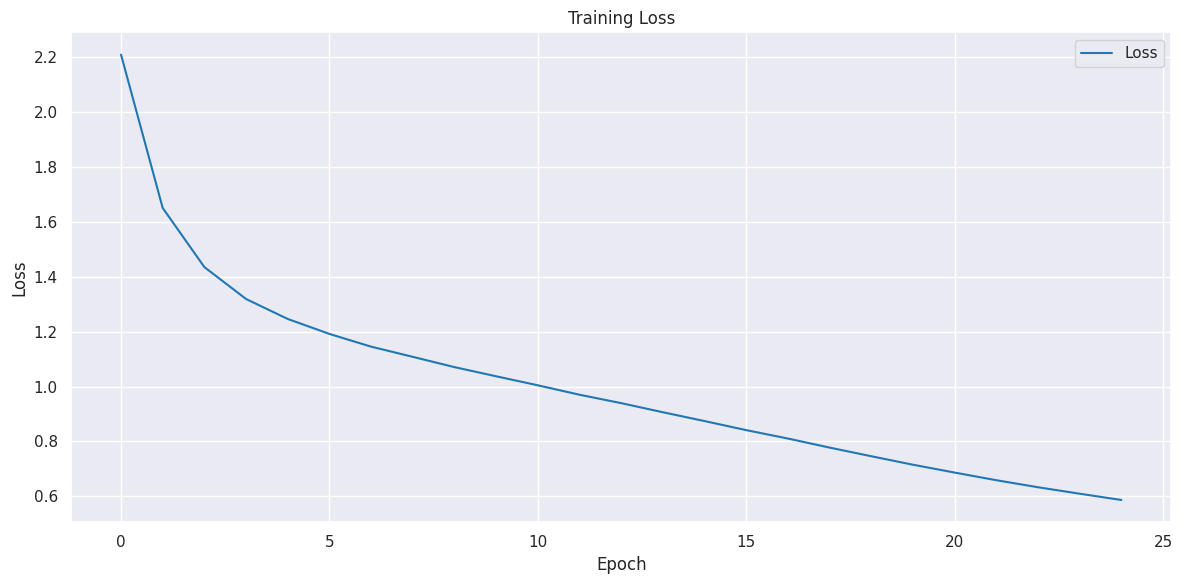

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns


# Plot learning curve
def plot_loss(history, title="Training Loss"):
    sns.set(style="darkgrid")
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['loss'], label='Loss', color='tab:blue')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_loss(history)


# Phase 5: Text Prediction - Export Trained RNN Model to ONNX

In [71]:
# Use flexible input shape: (batch_size, sequence_length)
spec = (tf.TensorSpec([None, None], tf.int32, name="input"),)

# Convert to ONNX
onnx_model, _ = tf2onnx.convert.from_keras(
    model,
    input_signature=spec,
    opset=13
)

onnx.save(onnx_model, "/mnt/mls/models/tf/moby_rnn.onnx")
print("Exported successfully.")


I0000 00:00:1746244180.723108  831364 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1746244180.723179  831364 single_machine.cc:374] Starting new session
I0000 00:00:1746244180.736957  831364 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 19022 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1746244180.862229  831364 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 19022 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1746244180.881512  831364 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1746244180.881625  831364 single_machine.cc:374] Starting new session
I0000 00:00:1746244180.887023  831364 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 19022

Exported successfully.


In [72]:
# Optional: Display Model Summary
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 64)       │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, None, 1026)     │     3,361,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, None, 44)       │        45,188 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,227,542 (39.01 MB)

 Trainable params: 3,409,180 (13.00 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,818,362 (26.01 MB)

In [73]:
# Text Generation Function
def generate_text(model, start_seed, gen_size=1000, temp=1.0):
    input_eval = [char_to_ind[s] for s in start_seed]
    input_eval = tf.expand_dims(input_eval, 0)
    text_generated = []
    temperature = temp

    for layer in model.layers:
        if hasattr(layer, 'reset_states'):
            layer.reset_states()

    for i in range(gen_size):
        predictions = model(input_eval)
        predictions = tf.squeeze(predictions, axis=0)
        predictions = predictions / temperature
        predicted_id = tf.random.categorical(predictions, num_samples=1)[-1, 0].numpy()
        input_eval = tf.expand_dims([predicted_id], 0)
        text_generated.append(ind_to_char[predicted_id])

    return start_seed + ''.join(text_generated)


In [74]:
# Generate Sample Output
print(generate_text(model, "help", gen_size=1000, temp=0.5))


help mere ve in the ome an atharind an borine in in tin atthe me the anthe s s chery ote ate thenchan s ar ran warinthely ithin atind, wore athe whand s sthangrin ande bery tout the s arathe s thethe ous me buspe an f ane bure d on othery oly ar on an sthe t orine theris s ilinghe atins the th ff wararer ome me me ware t the boret che ary sthe ste thede, ontin t on f on bon wan boughe athe sthere bon aran in ath andin tin athis ty thandithan ve ared ore tis the bond s thithe an t ware s oph inan th o tot the an omanth and t at thanin ond on an an t s omanx are inde bome ine me od the an ond, boutithenghes an ind it s anthe bod s t tit ft bore phin abomorithethome t t ore the bouthe bethan on me me therin ine aren te an the on meranch wan atheranad the thathind an the an arabouthe t sthe ware i in inthesthile fly an the omed arande itinthe the be an athath th s tithe bourithe s in bughe an the then t ongran the tinde tite bouche the than arin the the fut the wringrome t s me ant t t fug

In [75]:
# Input Sanity Check
for c in "flower":
    assert c in char_to_ind, f"Missing: {c}"


In [76]:
# Tensor Shape Demonstration (Sanity Check)
tensor = tf.constant([[[1], [2], [3], [4], [5]]])
print("Original shape:", tensor.shape)
squeezed_tensor = tf.squeeze(tensor)
print("Squeezed shape:", squeezed_tensor.shape)


Original shape: (1, 5, 1)
Squeezed shape: (5,)


In [79]:
print(generate_text(model, "help", gen_size=1000, temp=.7))


help omphan anaratry orqureret spharite aty aran the ind t me tind in me ind sphi bourafie arinind ithere istomery s igulin waly o me the re ily anghin, athe alanghe man watere s in t ous bust spon iphere thathe. ffofury bofusthore uth wirin bed an bongrane me me s ve, melingrin the the ore othe wry ten t stheare ffity outheranin sthanar5 sth at ombe the wame and asterme in tetly itheve f t oph ondinde ieve in in s ther apheran thedit ins in in ie poutheran sthe andin wile be-trore te cuthe witous fugriphist i ont there aran sthe me ome dinghes sthe charin the tlererout me ten f me mbongh buthen bophe bok bus omedere st omerangrilederatithe sphe aringugrind the ath tere an strenatod ok bomerone ane itre it onerarin the ti tored ve on fut arate therithe aton thon outheth ato fe ouly ophe ouche thererenaly an an furapone me aran s t in athed t thad te arinan s on anan t bughate ind wh ome angre t oronanan omonin fury ithe alafulitin thede s sphe th, orary ily sphitheze mere an s the oust